In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import shap
import matplotlib.pyplot as plt

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [90]:
merged_df = pd.read_csv('merged_df.csv')
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone
0,2025-08-13 00:00:00,21.4,29.93,32.71,68.37,70.87,2.06,204.50,0.0,0.0,26.19,11.21,14.96
1,2025-08-13 01:00:00,21.4,29.93,32.71,68.37,70.82,1.47,234.78,0.0,0.0,26.13,11.04,14.61
2,2025-08-13 02:00:00,21.4,29.93,32.71,68.36,70.93,2.18,205.64,0.0,0.0,26.26,11.36,16.14
3,2025-08-13 03:00:00,21.4,29.93,32.71,68.36,71.05,1.73,207.66,0.0,0.2,26.39,15.19,14.63
4,2025-08-13 04:00:00,21.4,29.93,32.71,68.35,70.90,1.85,207.88,0.0,0.0,26.23,17.10,11.88


In [91]:
merged_df['TIMESTAMP'] = pd.to_datetime(merged_df['TIMESTAMP'])

# Example: resampling
merged_df = merged_df.set_index('TIMESTAMP').resample('D').mean().reset_index()

# Handle missing values
#merged_df = merged_df.fillna(method="ffill").dropna()

In [92]:
#Feature Engineering
merged_df["hour"] = merged_df["TIMESTAMP"].dt.hour
merged_df["day"] = merged_df["TIMESTAMP"].dt.day
merged_df["month"] = merged_df["TIMESTAMP"].dt.month

In [93]:
timestamps = merged_df['TIMESTAMP']

In [67]:
X = merged_df.drop(columns=['TIMESTAMP', 'target', 'impact'], errors='ignore')

In [94]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone,hour,day,month
0,2025-08-13,21.400000,29.930000,32.700833,68.302500,71.305417,1.847917,198.041250,29.435000,0.041667,26.703750,14.175417,30.780417,0,13,8
1,2025-08-14,21.409167,29.930000,32.680000,68.151250,71.781250,1.728333,201.519167,33.890417,0.041667,27.275833,14.220000,33.388750,0,14,8
2,2025-08-15,21.416190,29.930000,32.659048,68.000000,71.440952,1.803333,200.939048,7.365238,0.071429,26.895714,13.581429,32.473810,0,15,8
3,2025-08-16,21.423750,29.930000,32.637917,67.850417,71.548333,1.605833,182.342917,5.927917,0.758333,27.083333,14.660833,31.632917,0,16,8
4,2025-08-17,21.431250,29.938333,32.617083,67.700000,70.860833,1.744583,200.883750,8.055833,0.312500,26.261667,13.083333,37.605417,0,17,8


In [95]:
#Lag Features
for lag in [1, 3, 6, 12, 24, 48, 168]:
    merged_df[f"PM25_lag_{lag}"] = merged_df["PM2.5"].shift(lag)
    merged_df[f"PM10_lag_{lag}"] = merged_df["PM10"].shift(lag)

In [96]:
merged_df.columns

Index(['TIMESTAMP', 'PM2.5', 'PM10', 'TEMPERATURE', 'HUMIDITY', 'RH', 'WS',
       'WD', 'SR', 'RF', 'AT', 'NO2', 'Ozone', 'hour', 'day', 'month',
       'PM25_lag_1', 'PM10_lag_1', 'PM25_lag_3', 'PM10_lag_3', 'PM25_lag_6',
       'PM10_lag_6', 'PM25_lag_12', 'PM10_lag_12', 'PM25_lag_24',
       'PM10_lag_24', 'PM25_lag_48', 'PM10_lag_48', 'PM25_lag_168',
       'PM10_lag_168'],
      dtype='object')

In [97]:
#Rolling Features
merged_df["PM25_roll_mean_6"] = merged_df["PM2.5"].rolling(6).mean()
merged_df["PM10_roll_mean_6"] = merged_df["PM10"].rolling(6).mean()

In [98]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM25_lag_12,PM10_lag_12,PM25_lag_24,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6
0,2025-08-13,21.400000,29.930000,32.700833,68.302500,71.305417,1.847917,198.041250,29.435000,0.041667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-14,21.409167,29.930000,32.680000,68.151250,71.781250,1.728333,201.519167,33.890417,0.041667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-15,21.416190,29.930000,32.659048,68.000000,71.440952,1.803333,200.939048,7.365238,0.071429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-16,21.423750,29.930000,32.637917,67.850417,71.548333,1.605833,182.342917,5.927917,0.758333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-17,21.431250,29.938333,32.617083,67.700000,70.860833,1.744583,200.883750,8.055833,0.312500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
#Wind Direction Conversion
merged_df["WD_sin"] = np.sin(np.deg2rad(merged_df["WD"]))
merged_df["WD_cos"] = np.cos(np.deg2rad(merged_df["WD"]))

In [100]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM25_lag_24,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6,WD_sin,WD_cos
0,2025-08-13,21.400000,29.930000,32.700833,68.302500,71.305417,1.847917,198.041250,29.435000,0.041667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.309702,-0.950834
1,2025-08-14,21.409167,29.930000,32.680000,68.151250,71.781250,1.728333,201.519167,33.890417,0.041667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.366812,-0.930295
2,2025-08-15,21.416190,29.930000,32.659048,68.000000,71.440952,1.803333,200.939048,7.365238,0.071429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.357375,-0.933961
3,2025-08-16,21.423750,29.930000,32.637917,67.850417,71.548333,1.605833,182.342917,5.927917,0.758333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.040880,-0.999164
4,2025-08-17,21.431250,29.938333,32.617083,67.700000,70.860833,1.744583,200.883750,8.055833,0.312500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.356473,-0.934306


In [101]:
merged_df1 = merged_df.dropna()

In [102]:
merged_df1.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM25_lag_24,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6,WD_sin,WD_cos
168,2026-01-28,17.404583,38.738750,26.176667,59.151250,66.006250,2.424167,198.876667,37.567917,0.000000,...,25.880417,35.600833,22.350000,29.99,21.400000,29.930000,6.962083,13.174444,-0.323532,-0.946217
169,2026-01-29,30.049167,55.947500,27.218333,56.703333,66.381667,2.349583,196.749583,39.861667,0.000000,...,21.556957,29.948261,22.357917,29.99,21.409167,29.930000,11.164514,21.438611,-0.288189,-0.957573
170,2026-01-30,37.711667,72.525000,28.042500,69.187917,67.272917,2.543333,203.833750,35.810833,0.000000,...,23.060625,31.205000,22.365417,29.99,21.416190,29.930000,16.715208,32.542292,-0.404084,-0.914722
171,2026-01-31,38.462083,77.600833,28.222083,72.853333,67.370000,2.331250,202.218750,37.477500,0.000000,...,21.419167,29.240833,22.372917,29.99,21.423750,29.930000,22.462014,44.568542,-0.378144,-0.925747
172,2026-02-01,40.032917,81.268333,25.890417,77.040833,65.546667,2.128750,178.525417,39.940000,0.004167,...,20.005000,26.442500,22.380000,29.99,21.431250,29.938333,28.541736,57.282639,0.025733,-0.999669


In [103]:
#Target Variable
merged_df["target"] = merged_df["PM2.5"]

In [104]:
merged_df.tail(5)

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6,WD_sin,WD_cos,target
209,2026-03-10,44.562500,84.541667,33.501667,35.713333,61.510000,1.902917,167.671667,97.637917,0.0,...,72.208333,5.687500,7.281667,21.724583,29.95,38.176815,70.009266,0.213514,-0.976940,44.562500
210,2026-03-11,55.715417,113.492917,31.781250,62.778333,66.100833,1.775417,193.469583,89.020417,0.0,...,73.145833,5.261250,6.821667,21.732083,29.95,42.207510,79.829266,-0.232929,-0.972494,55.715417
211,2026-03-12,54.809583,112.673750,31.971250,70.149583,69.176250,1.992500,204.525000,91.066667,0.0,...,65.163333,4.834583,6.362500,21.740000,29.95,45.713968,88.641210,-0.415090,-0.909780,54.809583
212,2026-03-13,51.048750,102.156250,32.880000,52.862500,67.317917,1.901250,207.812500,89.750833,0.0,...,77.302083,4.407500,5.902917,21.749167,29.95,47.596458,93.839236,-0.466580,-0.884479,51.048750
213,2026-03-14,31.327143,55.202143,31.889286,48.139286,70.302857,1.712143,196.900000,124.447857,0.0,...,60.203333,3.981250,5.443333,21.755789,29.95,46.459732,91.043065,-0.290702,-0.956814,31.327143


In [105]:
merged_df = merged_df.dropna()
merged_df.tail()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6,WD_sin,WD_cos,target
209,2026-03-10,44.562500,84.541667,33.501667,35.713333,61.510000,1.902917,167.671667,97.637917,0.0,...,72.208333,5.687500,7.281667,21.724583,29.95,38.176815,70.009266,0.213514,-0.976940,44.562500
210,2026-03-11,55.715417,113.492917,31.781250,62.778333,66.100833,1.775417,193.469583,89.020417,0.0,...,73.145833,5.261250,6.821667,21.732083,29.95,42.207510,79.829266,-0.232929,-0.972494,55.715417
211,2026-03-12,54.809583,112.673750,31.971250,70.149583,69.176250,1.992500,204.525000,91.066667,0.0,...,65.163333,4.834583,6.362500,21.740000,29.95,45.713968,88.641210,-0.415090,-0.909780,54.809583
212,2026-03-13,51.048750,102.156250,32.880000,52.862500,67.317917,1.901250,207.812500,89.750833,0.0,...,77.302083,4.407500,5.902917,21.749167,29.95,47.596458,93.839236,-0.466580,-0.884479,51.048750
213,2026-03-14,31.327143,55.202143,31.889286,48.139286,70.302857,1.712143,196.900000,124.447857,0.0,...,60.203333,3.981250,5.443333,21.755789,29.95,46.459732,91.043065,-0.290702,-0.956814,31.327143


In [106]:
merged_df.columns

Index(['TIMESTAMP', 'PM2.5', 'PM10', 'TEMPERATURE', 'HUMIDITY', 'RH', 'WS',
       'WD', 'SR', 'RF', 'AT', 'NO2', 'Ozone', 'hour', 'day', 'month',
       'PM25_lag_1', 'PM10_lag_1', 'PM25_lag_3', 'PM10_lag_3', 'PM25_lag_6',
       'PM10_lag_6', 'PM25_lag_12', 'PM10_lag_12', 'PM25_lag_24',
       'PM10_lag_24', 'PM25_lag_48', 'PM10_lag_48', 'PM25_lag_168',
       'PM10_lag_168', 'PM25_roll_mean_6', 'PM10_roll_mean_6', 'WD_sin',
       'WD_cos', 'target'],
      dtype='object')

In [107]:
merged_df = merged_df.drop(columns=['AQI', 'day_of_week'], errors='ignore')

In [108]:
merged_df.to_csv('sensor_data1.csv', index=False)

In [109]:
feature_cols = joblib.load("features.pkl")

In [110]:
print("Missing:", set(feature_cols) - set(merged_df.columns))
print("Extra:", set(merged_df.columns) - set(feature_cols))

Missing: set()
Extra: {'PM25_lag_3', 'PM10_lag_12', 'PM25_lag_1', 'WD_sin', 'WD_cos', 'TIMESTAMP', 'PM10_lag_168', 'target', 'PM25_roll_mean_6', 'PM10_lag_6', 'PM10_roll_mean_6', 'PM10_lag_1', 'PM25_lag_12', 'PM10_lag_24', 'PM25_lag_48', 'PM10_lag_3', 'PM25_lag_6', 'PM25_lag_24', 'PM10_lag_48', 'PM25_lag_168'}


In [56]:
#merged_df = merged_df.drop(columns=['TIMESTAMP', 'target', 'impact'], errors='ignore')

In [86]:
# Step 2: Match exact training features
merged_df = merged_df[feature_cols]

# Step 3: Handle NaN (from lag features)
merged_df = merged_df.fillna(0)

# Step 4: Predict
predictions = xgb_model.predict(merged_df)

In [87]:
joblib.dump(X.columns, "features.pkl")

['features.pkl']

In [89]:
#Train-Test Split
X = merged_df.drop(["target", "TIMESTAMP"], axis=1)
y = merged_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

KeyError: "['target', 'TIMESTAMP'] not found in axis"

XGBoost Model

In [28]:
xgb_model = XGBRegressor(n_estimators=200, max_depth=6)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost MAE: 5.637477891833523
XGBoost R2: 0.33126360785774633


SHAP Explainability

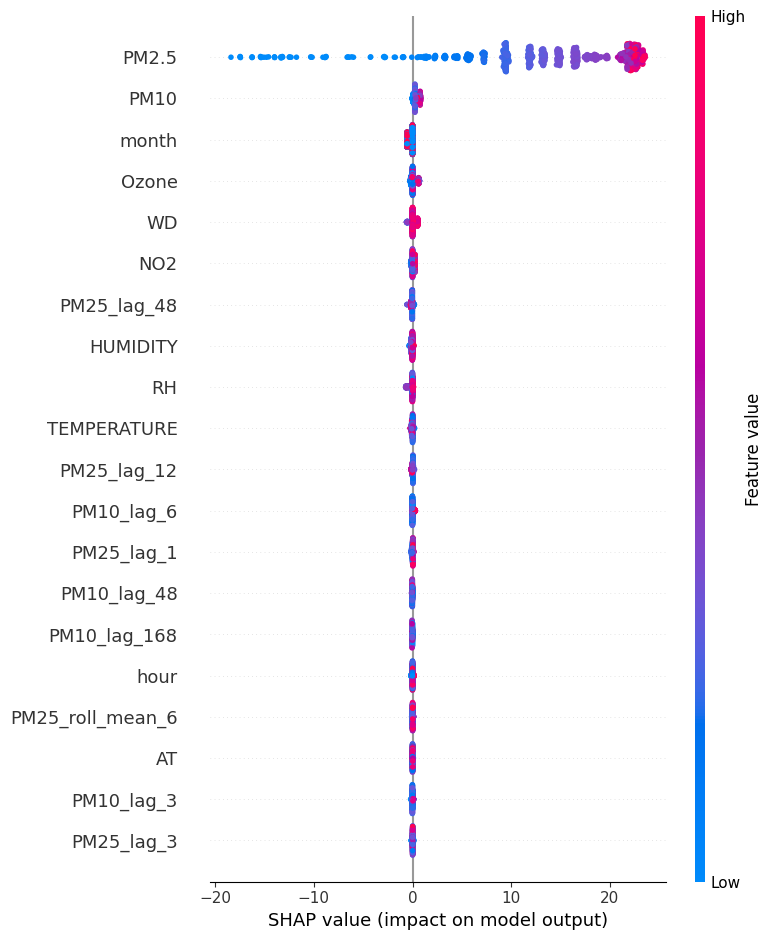

In [30]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

LSTM MODEL
PREPARE SEQUENCE

In [31]:
def create_sequences(X, y, seq_length=24):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X.iloc[i:i+seq_length].values)
        ys.append(y.iloc[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 24

X_lstm, y_lstm = create_sequences(X, y, seq_length)

split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

BUILD MODEL

In [33]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X.shape[1])),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 257.2930
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 116.2646
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 64.3515
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 36.4265
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 22.3977
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 16.0562
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 13.2212
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 12.3279
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 11.9117
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 11.2133
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 10.7593
Epoch 12/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.9255 
Epoch 13/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.5900
Epoch 14/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.2396
Epoch 15/20
116/116 ━━━━━━━━━

In [34]:
lstm_pred = lstm_model.predict(X_test_lstm)

print("LSTM MAE:", mean_absolute_error(y_test_lstm, lstm_pred))
print("LSTM R2:", r2_score(y_test_lstm, lstm_pred))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
LSTM MAE: 15.142326963966685
LSTM R2: -0.38238235968591305


7 DAYS PREDICTION MODEL

In [35]:
def forecast_lstm(model, last_sequence, steps=168):
    preds = []
    current = last_sequence.copy()

    for _ in range(steps):
        pred = model.predict(current.reshape(1, seq_length, X.shape[1]))[0][0]
        preds.append(pred)

        current = np.roll(current, -1, axis=0)
        current[-1] = pred  # simplified update

    return preds

last_seq = X_lstm[-1]
future_preds = forecast_lstm(lstm_model, last_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━

In [36]:
def construction_decision(pm25):
    if pm25 < 100:
        return "Allowed"
    elif pm25 < 200:
        return "Restricted"
    else:
        return "Not Allowed"

decisions = [construction_decision(p) for p in future_preds]

SENSOR CONTRIBUTION LOGIN

In [ ]:
sensor_contribution = {}

for sensor_id in df["sensor_id"].unique():
    sensor_df = df[df["sensor_id"] == sensor_id]
    sensor_contribution[sensor_id] = sensor_df["PM2.5"].mean()

# Most polluting sensor
max_sensor = max(sensor_contribution, key=sensor_contribution.get)

print("Highest contributing sensor:", max_sensor)

ADVANCE CONTRIBUTION

In [ ]:
baseline = merged_df["PM2.5"].mean()

merged_df["impact"] = merged_df["PM2.5"] - baseline

sensor_impact = merged_df.groupby("sensor_id")["impact"].mean()
print(sensor_impact.sort_values(ascending=False))

MODEL SELECTION

In [39]:
xgb_score = r2_score(y_test, xgb_pred)
lstm_score = r2_score(y_test_lstm, lstm_pred)

if xgb_score > lstm_score:
    final_model = "XGBoost"
else:
    final_model = "LSTM"

print("Best Model:", final_model)

Best Model: XGBoost


HYBRID MODEL

In [40]:
min_len = min(len(xgb_pred), len(lstm_pred))

ensemble_pred = (
    xgb_pred[:min_len] + lstm_pred.flatten()[:min_len]
) / 2

print("Ensemble R2:", r2_score(y_test[:min_len], ensemble_pred))

Ensemble R2: 0.05455853539245892


In [41]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [42]:
lstm_model.save("lstm_model.h5")

In [43]:
merged_df.columns

Index(['TIMESTAMP', 'PM2.5', 'PM10', 'TEMPERATURE', 'HUMIDITY', 'RH', 'WS',
       'WD', 'SR', 'RF', 'AT', 'NO2', 'Ozone', 'hour', 'day', 'month',
       'PM25_lag_1', 'PM10_lag_1', 'PM25_lag_3', 'PM10_lag_3', 'PM25_lag_6',
       'PM10_lag_6', 'PM25_lag_12', 'PM10_lag_12', 'PM25_lag_24',
       'PM10_lag_24', 'PM25_lag_48', 'PM10_lag_48', 'PM25_lag_168',
       'PM10_lag_168', 'PM25_roll_mean_6', 'PM10_roll_mean_6', 'WD_sin',
       'WD_cos', 'target', 'impact'],
      dtype='object')

In [46]:
merged_df.to_csv('merged_data.csv', index=False)

In [3]:
# 2. Create target
merged_df['CAN_WORK'] = ((merged_df['PM2.5'] < 60) & (merged_df['PM10'] < 100) & (merged_df['WS'] > 1) & (merged_df['RF'] == 0)).astype(int)

In [4]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone,CAN_WORK
0,2025-08-13 00:00:00,21.4,29.93,32.71,68.37,70.87,2.06,204.50,0.0,0.0,26.19,11.21,14.96,1
1,2025-08-13 01:00:00,21.4,29.93,32.71,68.37,70.82,1.47,234.78,0.0,0.0,26.13,11.04,14.61,1
2,2025-08-13 02:00:00,21.4,29.93,32.71,68.36,70.93,2.18,205.64,0.0,0.0,26.26,11.36,16.14,1
3,2025-08-13 03:00:00,21.4,29.93,32.71,68.36,71.05,1.73,207.66,0.0,0.2,26.39,15.19,14.63,0
4,2025-08-13 04:00:00,21.4,29.93,32.71,68.35,70.90,1.85,207.88,0.0,0.0,26.23,17.10,11.88,1


In [5]:
# 4. Feature selection for each task
features_weather = ['NO2', 'Ozone', 'RH', 'WS', 'WD', 'SR', 'RF', 'AT']
features_site = ['pm25', 'pm10', 'temp_site', 'humidity_site']

In [6]:
# 5. Attribution: which site sensor causes pollution
from sklearn.ensemble import RandomForestRegressor
X_bg = merged_df[features_weather]
y_bg = merged_df['PM2.5']
rf_bg = RandomForestRegressor().fit(X_bg, y_bg)
merged_df['residual_pm25'] = merged_df['PM2.5'] - rf_bg.predict(X_bg)

In [7]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone,CAN_WORK,residual_pm25
0,2025-08-13 00:00:00,21.4,29.93,32.71,68.37,70.87,2.06,204.50,0.0,0.0,26.19,11.21,14.96,1,-0.0183
1,2025-08-13 01:00:00,21.4,29.93,32.71,68.37,70.82,1.47,234.78,0.0,0.0,26.13,11.04,14.61,1,-0.0311
2,2025-08-13 02:00:00,21.4,29.93,32.71,68.36,70.93,2.18,205.64,0.0,0.0,26.26,11.36,16.14,1,-0.0238
3,2025-08-13 03:00:00,21.4,29.93,32.71,68.36,71.05,1.73,207.66,0.0,0.2,26.39,15.19,14.63,0,-0.1563
4,2025-08-13 04:00:00,21.4,29.93,32.71,68.35,70.90,1.85,207.88,0.0,0.0,26.23,17.10,11.88,1,-0.0513
